In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

PROCESSED = '../data/processed/'

df_fund = pd.read_csv(PROCESSED + '01_fund_master.csv')
df_nav = pd.read_csv(PROCESSED + '02_nav_history.csv', parse_dates=['date'])
df_returns = pd.read_csv(PROCESSED + 'returns_computed.csv', parse_dates=['date'])
df_sharpe = pd.read_csv(PROCESSED + 'sharpe_values.csv')
df_tx = pd.read_csv(PROCESSED + '08_investor_transactions.csv', parse_dates=['transaction_date'])

# Task 1: Historical VaR & CVaR (95%)

In [3]:
def compute_var_cvar(returns_series, confidence=0.95):
    """
    VaR = 5th percentile of return distribution (worst 5% cutoff)
    CVaR = average of all returns WORSE than VaR (tail risk)
    """
    if len(returns_series) < 30:
        return None, None
    var = np.percentile(returns_series, (1 - confidence) * 100)
    cvar = returns_series[returns_series <= var].mean()
    return round(var * 100, 3), round(cvar * 100, 3)

var_cvar_results = []
for code in df_fund['amfi_code'].unique():
    fund_returns = df_returns[df_returns['amfi_code'] == code]['daily_return']
    var, cvar = compute_var_cvar(fund_returns)
    fund_name = df_fund[df_fund['amfi_code'] == code]['scheme_name'].values[0]
    var_cvar_results.append({
        'amfi_code': code, 'scheme_name': fund_name,
        'var_95_pct': var, 'cvar_95_pct': cvar
    })

df_var_cvar = pd.DataFrame(var_cvar_results).dropna().sort_values('var_95_pct')

print("Top 10 Highest-Risk Funds (worst VaR):")
print(df_var_cvar.head(10).to_string())

df_var_cvar.to_csv(PROCESSED + 'var_cvar_report.csv', index=False)
print(" ----> var_cvar_report.csv saved")

Top 10 Highest-Risk Funds (worst VaR):
    amfi_code                                         scheme_name  var_95_pct  cvar_95_pct
29     101207              ABSL Small Cap Fund - Regular - Growth      -2.391       -3.029
27     119095              Axis Small Cap Fund - Regular - Growth      -2.328       -2.969
3      119599           SBI Small Cap Fund - Direct Plan - Growth      -2.316       -3.016
17     118634      Nippon India Small Cap Fund - Regular - Growth      -2.281       -2.994
39     149324               DSP Small Cap Fund - Regular - Growth      -2.152       -2.857
2      119598          SBI Small Cap Fund - Regular Plan - Growth      -2.150       -2.844
26     119094                 Axis Midcap Fund - Regular - Growth      -1.700       -2.237
21     120842       Kotak Emerging Equity Fund - Regular - Growth      -1.695       -2.125
7      100033  HDFC Mid-Cap Opportunities Fund - Regular - Growth      -1.690       -2.185
32     102886                 UTI Mid Cap Fund - Re

# Task 2: Rolling 90-day Sharpe

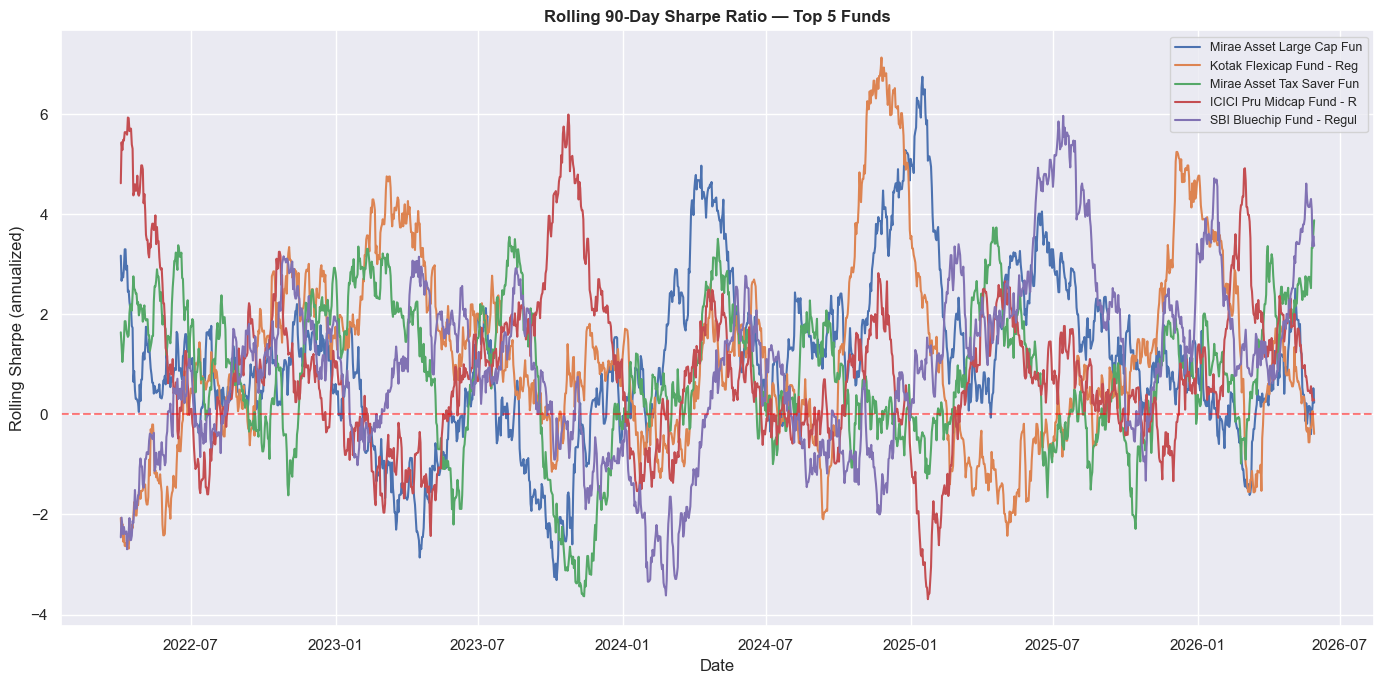

 ----> Rolling Sharpe chart done


In [4]:

RISK_FREE_RATE = 0.065
TRADING_DAYS = 252

top5_sharpe_codes = df_sharpe.sort_values('sharpe_ratio_computed', ascending=False)['amfi_code'].head(5).tolist()

plt.figure(figsize=(14, 7))
for code in top5_sharpe_codes:
    fund_ret = df_returns[df_returns['amfi_code'] == code].sort_values('date').set_index('date')['daily_return']
    rf_daily = RISK_FREE_RATE / TRADING_DAYS
    rolling_sharpe = (fund_ret.rolling(90).mean() - rf_daily) / fund_ret.rolling(90).std() * np.sqrt(TRADING_DAYS)
    fund_name = df_fund[df_fund['amfi_code']==code]['scheme_name'].values[0][:25]
    plt.plot(rolling_sharpe.index, rolling_sharpe, label=fund_name, linewidth=1.5)

plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.title('Rolling 90-Day Sharpe Ratio — Top 5 Funds', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Rolling Sharpe (annualized)')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../reports/charts/12_rolling_sharpe_chat.png', dpi=150)
plt.show()
print(" ----> Rolling Sharpe chart done")

# Task 3: Investor Cohort Analysis

In [5]:
first_tx = df_tx.groupby('investor_id')['transaction_date'].min().reset_index()
first_tx['cohort_year'] = first_tx['transaction_date'].dt.year
df_tx_cohort = df_tx.merge(first_tx[['investor_id','cohort_year']], on='investor_id')

sip_tx = df_tx_cohort[df_tx_cohort['transaction_type']=='Sip']

cohort_summary = sip_tx.groupby('cohort_year').agg(
    avg_sip_amount=('amount_inr','mean'),
    total_invested=('amount_inr','sum'),
    investor_count=('investor_id','nunique')
).round(2)

top_fund_per_cohort = df_tx_cohort.groupby(['cohort_year','amfi_code']).size().reset_index(name='count')
top_fund_per_cohort = top_fund_per_cohort.loc[top_fund_per_cohort.groupby('cohort_year')['count'].idxmax()]
top_fund_per_cohort = top_fund_per_cohort.merge(df_fund[['amfi_code','scheme_name']], on='amfi_code')

cohort_summary = cohort_summary.merge(
    top_fund_per_cohort[['cohort_year','scheme_name']], on='cohort_year'
).rename(columns={'scheme_name':'top_preferred_fund'})

print("Investor Cohort Summary:")
print(cohort_summary.to_string())

Investor Cohort Summary:
   cohort_year  avg_sip_amount  total_invested  investor_count                                     top_preferred_fund
0         2024        10996.89       214978121            4624  Mirae Asset Emerging Bluechip Fund - Regular - Growth
1         2025        13505.21         2255370             138              SBI Small Cap Fund - Direct Plan - Growth


# Task 4: SIP Continuity Analysis

In [6]:
sip_only = df_tx[df_tx['transaction_type']=='Sip'].sort_values(['investor_id','transaction_date'])

sip_counts = sip_only.groupby('investor_id').size()
eligible_investors = sip_counts[sip_counts >= 6].index
sip_eligible = sip_only[sip_only['investor_id'].isin(eligible_investors)]

sip_eligible['gap_days'] = sip_eligible.groupby('investor_id')['transaction_date'].diff().dt.days

continuity = sip_eligible.groupby('investor_id')['gap_days'].mean().reset_index()
continuity.columns = ['investor_id','avg_gap_days']
continuity['at_risk'] = continuity['avg_gap_days'] > 35

print(f"Investors with 6+ SIPs: {len(eligible_investors)}")
print(f"At-risk investors (avg gap > 35 days): {continuity['at_risk'].sum()}")
print(f"At-risk rate: {continuity['at_risk'].mean()*100:.1f}%")
print()
print(continuity.sort_values('avg_gap_days', ascending=False).head(10).to_string())

Investors with 6+ SIPs: 1362
At-risk investors (avg gap > 35 days): 1332
At-risk rate: 97.8%

     investor_id  avg_gap_days  at_risk
506    INV001890         102.6     True
323    INV001156         102.4     True
1188   INV004296         102.2     True
910    INV003325         101.0     True
150    INV000522         100.8     True
183    INV000608         100.2     True
503    INV001883          99.2     True
576    INV002166          99.2     True
380    INV001367          99.0     True
406    INV001491          98.8     True


# Task 5: Simple Fund Recommender

In [7]:
def recommend_funds(risk_appetite, top_n=3):
    """
    risk_appetite: 'Low', 'Moderate', 'High'
    """
    risk_map = {
        'Low': ['Low'],
        'Moderate': ['Moderate', 'Moderately High'],
        'High': ['High', 'Very High']
    }
    matching_risk = risk_map.get(risk_appetite, [])
    
    matched = df_fund[df_fund['risk_category'].isin(matching_risk)][['amfi_code','scheme_name','risk_category']]
    matched = matched.merge(df_sharpe[['amfi_code','sharpe_ratio_computed']], on='amfi_code')
    matched = matched.sort_values('sharpe_ratio_computed', ascending=False).head(top_n)
    
    print(f"\nTop {top_n} Recommended Funds for '{risk_appetite}' Risk Appetite:")
    print(matched[['scheme_name','risk_category','sharpe_ratio_computed']].to_string(index=False))
    return matched

recommend_funds('Low')
recommend_funds('Moderate')
recommend_funds('High')


Top 3 Recommended Funds for 'Low' Risk Appetite:
                                         scheme_name risk_category  sharpe_ratio_computed
        SBI Magnum Gilt Fund - Regular Plan - Growth           Low                -0.7431
Nippon India Gilt Securities Fund - Regular - Growth           Low                -0.8506
        HDFC Short Term Debt Fund - Regular - Growth           Low                -1.0399

Top 3 Recommended Funds for 'Moderate' Risk Appetite:
                                  scheme_name   risk_category  sharpe_ratio_computed
Mirae Asset Large Cap Fund - Regular - Growth        Moderate                 1.0682
       Kotak Flexicap Fund - Regular - Growth Moderately High                 0.9656
    SBI Bluechip Fund - Regular Plan - Growth        Moderate                 0.8610

Top 3 Recommended Funds for 'High' Risk Appetite:
                                  scheme_name risk_category  sharpe_ratio_computed
Mirae Asset Tax Saver Fund - Regular - Growth          High  

,amfi_code,scheme_name,risk_category,sharpe_ratio_computed
11,148569,Mirae Asset Tax Saver Fund - Regular - Growth,High,0.9190
4,120505,ICICI Pru Midcap Fund - Regular - Growth,High,0.8833
12,149323,DSP Midcap Fund - Regular - Growth,High,0.8329


# Task 6: Sector HHI Concentration

In [8]:
df_holdings = pd.read_csv(PROCESSED + '09_portfolio_holdings.csv')

def compute_hhi(weights_pct):
    weights_decimal = weights_pct / 100
    return round((weights_decimal ** 2).sum() * 10000, 1)  # scaled 0-10000, standard HHI convention

hhi_results = []
for code in df_holdings['amfi_code'].unique():
    fund_sectors = df_holdings[df_holdings['amfi_code']==code].groupby('sector')['weight_pct'].sum()
    hhi = compute_hhi(fund_sectors)
    fund_name = df_fund[df_fund['amfi_code']==code]['scheme_name'].values[0] if code in df_fund['amfi_code'].values else 'Unknown'
    hhi_results.append({'amfi_code': code, 'scheme_name': fund_name, 'hhi': hhi})

df_hhi = pd.DataFrame(hhi_results).sort_values('hhi', ascending=False)

print("Sector Concentration (HHI) — Higher = More Concentrated:")
print(df_hhi.to_string())
print()
print("HHI interpretation: <1500 = diversified | 1500-2500 = moderate | >2500 = highly concentrated")

Sector Concentration (HHI) — Higher = More Concentrated:
    amfi_code                                            scheme_name     hhi
19     119092                  Axis Bluechip Fund - Regular - Growth  2967.7
30     148569          Mirae Asset Tax Saver Fund - Regular - Growth  2549.9
7      125498      HDFC Mid-Cap Opportunities Fund - Direct - Growth  2531.6
27     102887                  UTI Flexi Cap Fund - Regular - Growth  2513.8
32     149323                     DSP Midcap Fund - Regular - Growth  2410.8
10     120505               ICICI Pru Midcap Fund - Regular - Growth  2387.0
15     118635                         Nippon India ETF Nifty 50 BeES  2375.0
3      119599              SBI Small Cap Fund - Direct Plan - Growth  2323.6
11     120506      ICICI Pru Value Discovery Fund - Regular - Growth  2314.6
6      100033     HDFC Mid-Cap Opportunities Fund - Regular - Growth  2276.5
1      119552               SBI Bluechip Fund - Direct Plan - Growth  2275.1
24     101207      

# Task 7: Markdown findings

## Advanced Analytics — Key Insights

1. **Highest VaR risk**: ABSL Small Cap Fund - Regular - Growth shows the worst 95% VaR at -2.39%, meaning on the worst 5% of trading days, this fund can lose more than 2.39% in a single day — consistent with Small Cap funds carrying the highest volatility in the portfolio.

2. **Cohort behavior**: Investors who joined in 2025 have the highest average SIP amount (₹13,505) versus ₹10,997 for the 2024 cohort, though the 2024 cohort dominates by volume (4,624 investors, ₹21.5 Cr total invested) — the sample simply hasn't accumulated later cohorts yet given the 2024–2025 transaction window.

3. **SIP continuity**: Of 1,362 investors with 6+ SIP transactions, 97.8% show an average gap greater than 35 days between contributions — a very high lapse-risk rate that suggests most "regular" SIP investors are still not maintaining strict monthly cadence.

4. **Sector concentration**: Axis Bluechip Fund shows the highest HHI at 2,968, followed by Mirae Asset Tax Saver (2,550) and HDFC Mid-Cap Opportunities (2,532) — all above the 2,500 "highly concentrated" threshold, meaning even large-cap-labeled funds carry meaningful single-sector risk.

5. **Recommender validation**: For 'High' risk appetite, Mirae Asset Tax Saver Fund tops the recommendation list with a Sharpe ratio of 0.919 — the highest among High/Very High risk category funds, confirming the recommender correctly surfaces the best risk-adjusted (not just highest raw return) option within the matching risk bucket.